In [1]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import pandas as pd
import ast
from pprint import pprint
import matplotlib.pyplot as plt
import pyproj
from shapely.geometry import LineString
from collections import defaultdict
import math
from haversine import haversine, Unit, inverse_haversine


# mappymatch imports
from mappymatch.constructs.trace import Trace
from mappymatch.maps.nx.nx_map import NxMap
from mappymatch.matchers.lcss.lcss import LCSSMatcher
pd.set_option('future.no_silent_downcasting', True)

from mappymatch.matchers.valhalla import ValhallaMatcher

In [ ]:
# Define your bounding box manually
north = 41.188771290159195
south = 41.13090363866696
west  = -8.699966476287791
east  = -8.559738123284369


bbox = (west, south, east, north)
# Fetch network from the bounding box
G_bbox = ox.graph_from_bbox(
    bbox=bbox,
    network_type="drive",   # can be 'drive', 'walk', etc.
    simplify=True,
)

# Project to local CRS (UTM Zone 29N, or Mercator 3857)
porto_crs = 3857
G_proj = ox.project_graph(G_bbox, to_crs=porto_crs)

In [20]:
# Create the smaller dataset

# traj_df = pd.read_csv("train.csv", nrows=15, index_col=0)
# traj_df.to_csv( "train_15.csv")

In [21]:
# read some of the trajectory data
# data is of the ofrm long, lat
traj_df = pd.read_csv("train_15.csv", index_col=0)

polylines = traj_df["POLYLINE"].to_numpy()
trajectories = []

for line in polylines:
    traj = ast.literal_eval(line)  # list of (lon, lat)
    trajectories.append(traj)


[1441.310395811928,
 172.31284230328717,
 109.72138355067082,
 407.7294859491036,
 158.36883015155425,
 77.12041967742208,
 199.16607417084148,
 185.1005014825983,
 183.99733599066616,
 145.67859226730766,
 145.23097718652568,
 4.9677786138183935,
 1.9789654706046214,
 14.149652315219088,
 9.06099057424558,
 41.078680725958996,
 215.6737972579364,
 99.93589524551761]


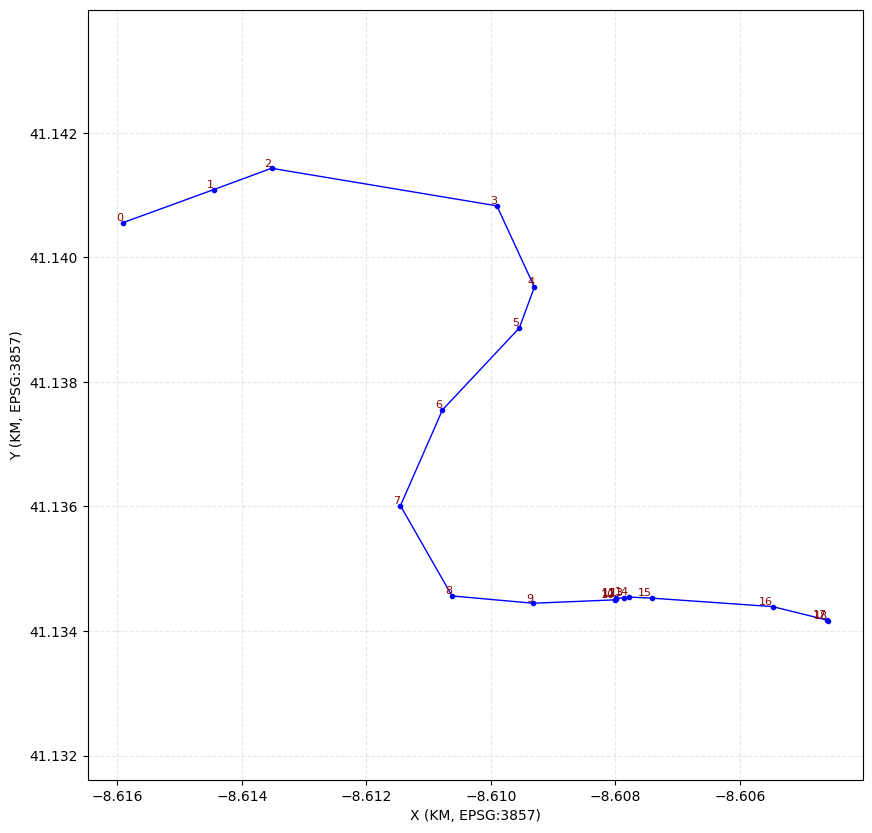

In [22]:
particular_traj = trajectories[9]
# compute_distances from previous popints, treat lat as x and long as y

rel_distances = []
for i in range(len(particular_traj[1:])):
    rel_distances.append(haversine(particular_traj[i], particular_traj[i-1], Unit.METERS))

pprint(rel_distances)

# Plot the line
plt.figure(figsize=(10,10))
x, y = zip(*particular_traj)
plt.plot(x, y, '-o', markersize=3, linewidth=1, color='blue')

# Annotate each point with its index
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, str(i), fontsize=8, ha='right', va='bottom', color='darkred')

# Styling
plt.axis('equal')
plt.xlabel("X (KM, EPSG:3857)")
plt.ylabel("Y (KM, EPSG:3857)")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()


Nearest nodes: 1771990365 2352439937
No edge exists. Adding a virtual one.


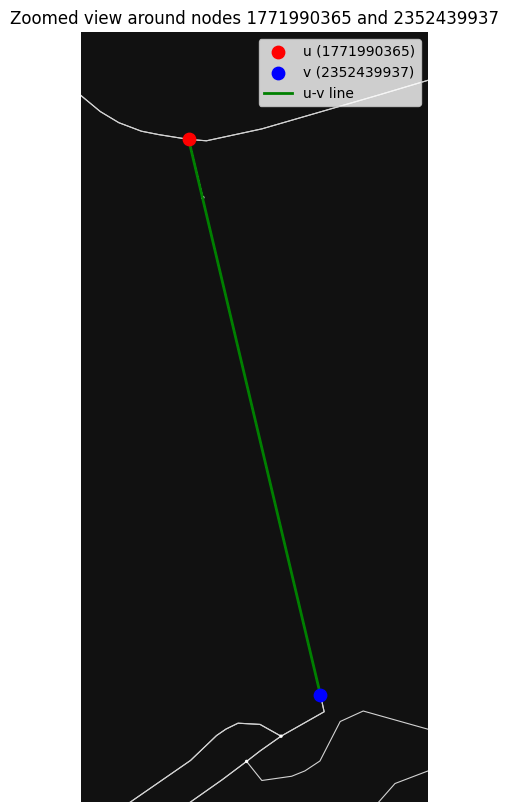

In [23]:
# Example GPS coordinates (lon, lat)
# Make sure order = (longitude, latitude)
p1 = trajectories[9][3]
p2 = trajectories[9][4]

# Your projected graph
transformer = pyproj.Transformer.from_crs("EPSG:4326", porto_crs, always_xy=True)

# Convert to projected coordinates
x1, y1 = transformer.transform(*p1)
x2, y2 = transformer.transform(*p2)

# Find nearest nodes in the projected graph
u = ox.distance.nearest_nodes(G_proj, X=x1, Y=y1)
v = ox.distance.nearest_nodes(G_proj, X=x2, Y=y2)

print("Nearest nodes:", u, v)

# Check if an edge exists
if G_proj.has_edge(u, v) or G_proj.has_edge(v, u):
    print("An edge already exists between these nodes.")
else:
    print("No edge exists. Adding a virtual one.")
    length = math.hypot(G_proj.nodes[v]['x'] - G_proj.nodes[u]['x'],
                        G_proj.nodes[v]['y'] - G_proj.nodes[u]['y'])
    G_proj.add_edge(u, v, length=length, highway='virtual')
    G_proj.add_edge(v, u, length=length, highway='virtual')  # optional (two-way)



# Plot base graph (same as yours)
fig, ax = ox.plot_graph(
    G_proj,
    figsize=(15, 10),
    node_size=6,
    node_color="white",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# Extract node coordinates
x_u, y_u = G_proj.nodes[u]['x'], G_proj.nodes[u]['y']
x_v, y_v = G_proj.nodes[v]['x'], G_proj.nodes[v]['y']

# Plot u (red) and v (blue)
ax.scatter([x_u], [y_u], c='red', s=80, zorder=5, label=f'u ({u})')
ax.scatter([x_v], [y_v], c='blue', s=80, zorder=5, label=f'v ({v})')

# Optional: line between them (green)
ax.plot([x_u, x_v], [y_u, y_v], c='green', lw=2, zorder=4, label='u-v line')

# Massive zoom: adjust limits to tightly focus on both points
pad = 50  # meters of padding, adjust as needed (smaller = tighter zoom)
minx, maxx = min(x_u, x_v) - pad, max(x_u, x_v) + pad
miny, maxy = min(y_u, y_v) - pad, max(y_u, y_v) + pad
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Add legend and title
ax.legend()
ax.set_title(f"Zoomed view around nodes {u} and {v}", fontsize=12)

plt.show()


In [24]:
# manually cleanse trajectories
trajectories[2] = [pt for i, pt in enumerate(trajectories[2]) if i not in {34,35}]
trajectories[3] = [pt for i, pt in enumerate(trajectories[3]) if i not in {15,16,17,18}]

# trajectories.pop(6) #remove route 7 for 1 sec

In [25]:
# Update trips to GeoDataSeries in same crs as porto_crs
trips = [  gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in traj],crs="EPSG:4326"  # convert from lat/long
        ).to_crs(porto_crs) 
    for traj in trajectories]

In [ ]:
# Base graph plot
fig, ax = ox.plot_graph(
    G_proj,
    figsize=(15,9),
    bgcolor="white",
    node_size=6,
    node_color="lightgray",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=0.6,
    show=False,
    close=False,
)
# fig.set_constrained_layout(True) 
# Vivid colors for trajectories
vivid_colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080",
    "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3"
]

# Plot each trajectory
for i, traj in enumerate(trips):
    x, y = traj.geometry.x, traj.geometry.y
    color = vivid_colors[i % len(vivid_colors)]  # wrap around if >15 trips
    ax.plot(
        x, y,
        color=color,
        marker="o",
        markersize=4,
        markeredgecolor="black",
        markeredgewidth=0.3,
        linewidth=2.5,
        alpha=0.9,
        zorder=3,
        label=f"Trip {i+1}"
    )

# Legend and title
ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

ax.set_title("First 15 Porto Trips on Road Network", fontsize=14, y=0.95)
fig.tight_layout()
fig.savefig("Images/raw_gps_plot_part_2.png", dpi=300, bbox_inches="tight", pad_inches=0)

plt.close(fig)


In [ ]:
G = G_proj.copy()

# Add geometry to edges that don't have it
for u, v, k, data in G.edges(keys=True, data=True):
    if 'geometry' not in data:
        point_u = (G.nodes[u]['x'], G.nodes[u]['y']) # x is long, y is lat
        point_v = (G.nodes[v]['x'], G.nodes[v]['y'])
        data['geometry'] = LineString([point_u, point_v])
             

# Ensure CRS is set
G.graph['crs'] = pyproj.CRS(porto_crs)
print(G.graph['crs'])
# Create NxMap and matcher
nx_map = NxMap(G)
matcher = LCSSMatcher(nx_map,
                      distance_epsilon  = 100,              # deafult = 50
                      similarity_cutoff  =0.9,                # default = 0.9
                      cutting_threshold=10,                 # default = 10
                      random_cuts=0,                        # default = 0
                      distance_threshold = 500)             # default = 10000, 


In [ ]:
# Collecting the output of map matching algorithm
# routes are a sequence of road segments that best fit the gps points, this is used in part 5.1 and part 4
# matched_dfs contain road segments each of which matches to a GPS point, used in part 5.2
# Note that len(routes[i]) >= len(matched_dfs[i]) because not each road link correponds to a gps point
# If a car moves too fast on a road link, between the gps collection, then no gps coordinate would be matched to that road link.
# So this road link wont appear in the matched_dfs but will appear in the route.

routes = []
matches_dfs = []

for i, traj in enumerate(trips): 
    print(f"---- Processing trips {i+1}/{len(trips)} ----")

    # Create Trace directly from GeoDataFrame (already in EPSG:3857)
    trace = Trace.from_geo_dataframe(traj, xy=False)  

    # Perform matching
    match_result = matcher.match_trace(trace)
    

    # Store per-coordinate matches for inspection
    matches_dfs.append(match_result.matches_to_dataframe()[["coordinate_id", "geom"]])

    # Extract the path, ie the list of routes
    # path is a sequence of road links, each of which stores id and geom, 
    # weonly store geom
    path = [ route.geom for route in match_result.path]
    # print(type(path[0]))
    routes.append(path)

    print(f"Matched to {len(routes[-1])} road segments")


In [ ]:
# correting for some trips

# Trip  3 contains a loop that cant be effectively solved for using LCSS, so trying with Valhalla
incorrect_trip_indexes = [2]
val_trips = [
    gpd.GeoDataFrame( geometry=[Point(lon, lat) for lon, lat in traj], crs="EPSG:4326")
    for traj in [trajectories[i] for i in incorrect_trip_indexes] # trip 3 is index 2
]

val_matcher = ValhallaMatcher()

val_routes = []
val_matched_dfs = []

for i, traj in enumerate(val_trips): 
    print(f"---- Processing trips {i+1}/{len(val_trips)} ----")

    # Create Trace directly from GeoDataFrame (in EPSG:4326 for Valhalla)
    trace = Trace.from_geo_dataframe(traj, xy=False)  

    # Perform matching
    match_result = val_matcher.match_trace(trace)

    # Store per-coordinate matches for inspection
    df = match_result.matches_to_dataframe()[["coordinate_id", "geom"]]
    df = gpd.GeoDataFrame(df, geometry="geom", crs="EPSG:4326").to_crs(porto_crs)
    val_matched_dfs.append(df)

    # Extract the path, ie the list of routes
    # path is a sequence of road links, each of which stores id and geom, 
    # we only store geom
    # reproject to the same geom as other geometries
    path = [ route.geom for route in match_result.path]
    path_series = gpd.GeoSeries(path, crs="EPSG:4326")
    path_proj = path_series.to_crs(porto_crs)
    line_list = list(path_proj)

    val_routes.append(line_list)

    print(f"Matched to {len(val_routes[-1])} road segments")

for index, route, val_df in zip(incorrect_trip_indexes, val_routes, val_matched_dfs):
    routes[index] = route
    matches_dfs[index] = val_df


In [ ]:

routes_edges = [] # This is not used for any analysis just for plotting
link_counts = {} # Used for most frequent road link tahken analysis

for i, route in enumerate(routes): 
    xx, yy = [], [] 
    for link in route: # each link is start, end, key
        try:
            link_counts[link] +=1
        except:
            link_counts[link] = 1

        x, y = link.xy 
        xx.extend(x) 
        yy.extend(y) 
    routes_edges.append([xx, yy])

# Bounding box of all routes
all_x = np.concatenate([r[0] for r in routes_edges])
all_y = np.concatenate([r[1] for r in routes_edges])
pad_x = (all_x.max() - all_x.min()) * 0.05
pad_y = (all_y.max() - all_y.min()) * 0.05

bbox = (all_y.min() - pad_y, all_y.max() + pad_y,
        all_x.min() - pad_x, all_x.max() + pad_x)
# --- Plot base OSM graph (limited to bbox) ---
fig, ax = ox.plot_graph(G_proj,
    bbox=bbox,figsize=(15, 8),
    node_size=6,node_color="white",edge_color="lightgray",edge_linewidth=0.8,
    show=False,close=False,
)

# --- Plot matched routes ---
for i, route_edge in enumerate(routes_edges):
    color = vivid_colors[i % len(vivid_colors)]
    ax.plot( route_edge[0], route_edge[1],color=color,linewidth=2.5,alpha=0.9,zorder=3,label=f"Route {i+1}")

# --- Styling ---
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# move title slightly up and ensure it's visible
ax.set_title("Matched Routes on Road Network", fontsize=14, pad=20)

ax.legend(loc="upper right",fontsize=8,frameon=True,facecolor="white",edgecolor="black")

ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# ensure tight layout doesn’t crop title
fig.tight_layout(rect=[0, 0, 1, 0.97], pad=0.5)

# --- Save & show ---
fig.savefig("Images/matched_routes_compact_part_4.png", dpi=300)
plt.close(fig)


In [ ]:
# linkcounts was calculated in the previous box

top_links = [k for k, _ in sorted(link_counts.items(), key=lambda x: x[1], reverse=True)[:15]]


# --- Plot base OSM graph (limited to bbox) ---
fig, ax = ox.plot_graph(G_proj,bbox=bbox,figsize=(15, 8),node_size=6,node_color="white",edge_color="lightgray",edge_linewidth=0.8,show=False,close=False,)

# --- Plot top links ---
for i, link in enumerate(top_links):
    x, y = link.xy
    ax.plot(x, y,linewidth=3,alpha=0.8,zorder=4,label=f"Top Link {i+1}")

# --- Styling ---
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_title("Top 15 Most Traversed Links on Road Network", fontsize=14, pad=20)

ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# optional legend (can be omitted if cluttered)
ax.legend(loc="upper right",fontsize=8,frameon=True,facecolor="white",edgecolor="black")

fig.tight_layout(rect=[0, 0, 1, 0.97], pad=0.5)

# Save & show
fig.savefig("Images/top_links_on_network_part_5_1.png", dpi=300)
plt.close(fig)

In [ ]:
# Container: link_id -> [total_points, total_routes]
link_stats = defaultdict(lambda: [0, 0])
N = 15

# Iterate over routes
for traj_df in matches_dfs:
    # Count GPS points per link in this route
    traj_links = traj_df['geom'].value_counts().astype(float)  # link -> number of GPS points in this traj
    
    # Subtract 0.5 from first and last road_id
    first_link = traj_df.iloc[0]['geom']
    last_link = traj_df.iloc[-1]['geom']
    traj_links[first_link] -= 0.5
    traj_links[last_link] -= 0.5
    
    # Accumulate points and route count
    for link, count in traj_links.items():
        link_stats[link][0] += count       # accumulate GPS points
        link_stats[link][1] += 1           # increment number of trips that traversed this link

# Compute average GPS points per trajectory for each link
avg_points_per_route = {link: total_points/total_routes
                        for link, (total_points, total_routes) in link_stats.items()}

# Get top 10 links with largest average points per route
top_slowest = sorted(avg_points_per_route.items(), key=lambda x: x[1], reverse=True)[:N]

# Display results
for rank, (link, avg_points) in enumerate(top_slowest, start=1):
    print(f"{rank:2d}. Link {link} — average GPS points per trajectory: {avg_points:.2f}")


# top_slowest is a list of tuples: (link_id, avg_points)
top_slowest_geom = []
for link_geom, _ in top_slowest:
    x, y = link_geom.xy
    top_slowest_geom.append([x, y])

# --- Plot base OSM graph (limited to bbox) ---
fig, ax = ox.plot_graph(G_proj,bbox=bbox,figsize=(15, 8),node_size=6,node_color="white",edge_color="lightgray",edge_linewidth=0.8,show=False,close=False,)

# --- Plot top slowest links ---
for i, link_geom in enumerate(top_slowest_geom):
    x, y = link_geom
    ax.plot( x, y,linewidth=3,alpha=0.8,zorder=4,label=f"Slow Link {i+1}")

# --- Styling ---
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_title("Top 10 Slowest Links on Road Network (avg GPS points per route)", fontsize=14, pad=20)

ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# optional legend
ax.legend(loc="upper right",fontsize=8,frameon=True,facecolor="white",edgecolor="black")

fig.tight_layout(rect=[0, 0, 1, 0.97], pad=0.5)

# Save & show
fig.savefig("Images/top_slowest_links_part_5_2.png", dpi=300)
plt.close(fig)

